In [1]:
import pickle
import pandas as pd
import numpy as np

In [2]:
# Replace with your actual path if it's not in the same folder
with open("avoplotto.pkl", "rb") as f:
    data = pickle.load(f)
data


,date,type,year,avg_price,size,nb_sold
0,2015-12-27,conventional,2015,0.95,small,9626901.09
1,2015-12-20,conventional,2015,0.98,small,8710021.76
2,2015-12-13,conventional,2015,0.93,small,9855053.66
3,2015-12-06,conventional,2015,0.89,small,9405464.36
4,2015-11-29,conventional,2015,0.99,small,8094803.56
...,...,...,...,...,...,...
1009,2018-02-04,organic,2018,1.53,extra_large,1703.52
1010,2018-01-28,organic,2018,1.61,extra_large,1270.61
1011,2018-01-21,organic,2018,1.63,extra_large,1490.02
1012,2018-01-14,organic,2018,1.59,extra_large,1580.01


In [3]:
data['date'].min()

'2015-01-04'

In [4]:
data['date'].max()

'2018-03-25'

In [5]:
most_distribution = data['date'].mode()[0]
print(f'most_distribution: {most_distribution}')

most_distribution: 2015-01-04


In [6]:
data.value_counts

<bound method DataFrame.value_counts of             date          type  year  avg_price         size     nb_sold
0     2015-12-27  conventional  2015       0.95        small  9626901.09
1     2015-12-20  conventional  2015       0.98        small  8710021.76
2     2015-12-13  conventional  2015       0.93        small  9855053.66
3     2015-12-06  conventional  2015       0.89        small  9405464.36
4     2015-11-29  conventional  2015       0.99        small  8094803.56
...          ...           ...   ...        ...          ...         ...
1009  2018-02-04       organic  2018       1.53  extra_large     1703.52
1010  2018-01-28       organic  2018       1.61  extra_large     1270.61
1011  2018-01-21       organic  2018       1.63  extra_large     1490.02
1012  2018-01-14       organic  2018       1.59  extra_large     1580.01
1013  2018-01-07       organic  2018       1.51  extra_large     1289.07

[1014 rows x 6 columns]>

In [7]:
data.shape

(1014, 6)

In [8]:
data.describe()

,year,avg_price,nb_sold
count,1014.000000,1014.000000,1.014000e+03
mean,2016.147929,1.319024,4.167774e+06
std,0.940380,0.295168,5.596185e+06
min,2015.000000,0.760000,8.343000e+02
25%,2015.000000,1.040000,1.320755e+05
50%,2016.000000,1.325000,4.232327e+05
75%,2017.000000,1.540000,1.019066e+07
max,2018.000000,2.090000,2.274362e+07


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       1014 non-null   object 
 1   type       1014 non-null   object 
 2   year       1014 non-null   int64  
 3   avg_price  1014 non-null   float64
 4   size       1014 non-null   object 
 5   nb_sold    1014 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 47.7+ KB


In [10]:
data.index

RangeIndex(start=0, stop=1014, step=1)

In [11]:
data.columns

Index(['date', 'type', 'year', 'avg_price', 'size', 'nb_sold'], dtype='object')

In [12]:
condition = data['date'].isin(['2015-01-04'])
data[condition]

,date,type,year,avg_price,size,nb_sold
51,2015-01-04,conventional,2015,0.95,small,12357161.34
220,2015-01-04,organic,2015,1.46,small,233286.13
389,2015-01-04,conventional,2015,0.95,large,13624083.05
558,2015-01-04,organic,2015,1.46,large,216611.20
727,2015-01-04,conventional,2015,0.95,extra_large,844093.32
896,2015-01-04,organic,2015,1.46,extra_large,4370.99


In [13]:
def tripleTheSold(nb_sold):
    return nb_sold*3

data['3nb_sold'] = data['nb_sold'].agg(tripleTheSold)
data

/tmp/ipykernel_72410/2262383381.py:4: FutureWarning: using <function tripleTheSold at 0x7aaac0f930a0> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  data['3nb_sold'] = data['nb_sold'].agg(tripleTheSold)


,date,type,year,avg_price,size,nb_sold,3nb_sold
0,2015-12-27,conventional,2015,0.95,small,9626901.09,28880703.27
1,2015-12-20,conventional,2015,0.98,small,8710021.76,26130065.28
2,2015-12-13,conventional,2015,0.93,small,9855053.66,29565160.98
3,2015-12-06,conventional,2015,0.89,small,9405464.36,28216393.08
4,2015-11-29,conventional,2015,0.99,small,8094803.56,24284410.68
...,...,...,...,...,...,...,...
1009,2018-02-04,organic,2018,1.53,extra_large,1703.52,5110.56
1010,2018-01-28,organic,2018,1.61,extra_large,1270.61,3811.83
1011,2018-01-21,organic,2018,1.63,extra_large,1490.02,4470.06
1012,2018-01-14,organic,2018,1.59,extra_large,1580.01,4740.03


In [14]:
data.columns

Index(['date', 'type', 'year', 'avg_price', 'size', 'nb_sold', '3nb_sold'], dtype='object')

In [15]:
data.tail()

,date,type,year,avg_price,size,nb_sold,3nb_sold
1009,2018-02-04,organic,2018,1.53,extra_large,1703.52,5110.56
1010,2018-01-28,organic,2018,1.61,extra_large,1270.61,3811.83
1011,2018-01-21,organic,2018,1.63,extra_large,1490.02,4470.06
1012,2018-01-14,organic,2018,1.59,extra_large,1580.01,4740.03
1013,2018-01-07,organic,2018,1.51,extra_large,1289.07,3867.21


In [16]:
data['avg_price'].median()

np.float64(1.3250000000000002)

In [17]:
data['avg_price'].mean()

np.float64(1.3190236686390533)

In [18]:
data['avg_price'].min()

np.float64(0.76)

In [19]:
data['avg_price'].max()

np.float64(2.09)

In [20]:
data['avg_price'].mode()

0    1.0
Name: avg_price, dtype: float64

In [21]:
data['avg_price'].var()

np.float64(0.08712431730696216)

In [22]:
data['avg_price'].sum()

np.float64(1337.49)

In [23]:
data['3nb_sold'].sum()

np.float64(12678368908.019999)

In [24]:
data['avg_price'].std()

np.float64(0.2951682864180401)

In [25]:
data['avg_price'].quantile()

np.float64(1.3250000000000002)

In [26]:
help(pd.DataFrame.var)

Help on function var in module pandas.core.frame:

var(self, axis: 'Axis | None' = 0, skipna: 'bool' = True, ddof: 'int' = 1, numeric_only: 'bool' = False, **kwargs)
    Return unbiased variance over requested axis.
    
    Normalized by N-1 by default. This can be changed using the ddof argument.
    
    Parameters
    ----------
    axis : {index (0), columns (1)}
        For `Series` this parameter is unused and defaults to 0.
    
        .. warning::
    
            The behavior of DataFrame.var with ``axis=None`` is deprecated,
            in a future version this will reduce over both axes and return a scalar
            To retain the old behavior, pass axis=0 (or do not pass axis).
    
    skipna : bool, default True
        Exclude NA/null values. If an entire row/column is NA, the result
        will be NA.
    ddof : int, default 1
        Delta Degrees of Freedom. The divisor used in calculations is N - ddof,
        where N represents the number of elements.
    numeri

# Help on function mode in module pandas.core.frame:


mode(self, axis: 'Axis' = 0, numeric_only: 'bool' = False, dropna: 'bool' = True) -> 'DataFrame'
    Get the mode(s) of each element along the selected axis.
    
    The mode of a set of values is the value that appears most often.
    It can be multiple values.
    
    Parameters
    ----------
    axis : {0 or 'index', 1 or 'columns'}, default 0
        The axis to iterate over while searching for the mode:
    
        * 0 or 'index' : get mode of each column
        * 1 or 'columns' : get mode of each row.
    
    numeric_only : bool, default False
        If True, only apply to numeric columns.
    dropna : bool, default True
        Don't consider counts of NaN/NaT.
    
    Returns
    -------
    DataFrame
        The modes of each column or row.
    
    See Also
    --------
    Series.mode : Return the highest frequency value in a Series.
    Series.value_counts : Return the counts of values in a Series.
    
    Examples
    --------
    >>> df = pd.DataFrame([('bird', 2, 2),
    ...                    ('mammal', 4, np.nan),
    ...                    ('arthropod', 8, 0),
    ...                    ('bird', 2, np.nan)],
    ...                   index=('falcon', 'horse', 'spider', 'ostrich'),
    ...                   columns=('species', 'legs', 'wings'))
    >>> df
               species  legs  wings
    falcon        bird     2    2.0
    horse       mammal     4    NaN
    spider   arthropod     8    0.0
    ostrich       bird     2    NaN
    
    By default, missing values are not considered, and the mode of wings
    are both 0 and 2. Because the resulting DataFrame has two rows,
    the second row of ``species`` and ``legs`` contains ``NaN``.
    
    >>> df.mode()
      species  legs  wings
    0    bird   2.0    0.0
    1     NaN   NaN    2.0
    
    Setting ``dropna=False`` ``NaN`` values are considered and they can be
    the mode (like for wings).
    
    >>> df.mode(dropna=False)
      species  legs  wings
    0    bird     2    NaN
    
    Setting ``numeric_only=True``, only the mode of numeric columns is
    computed, and columns of other types are ignored.
    
    >>> df.mode(numeric_only=True)
       legs  wings
    0   2.0    0.0
    1   NaN    2.0
    
    To compute the mode over columns and not rows, use the axis parameter:
    
    >>> df.mode(axis='columns', numeric_only=True)
               0    1
    falcon   2.0  NaN
    horse    4.0  NaN
    spider   0.0  8.0
    ostrich  2.0  NaN

In [27]:
# The mode of a set of values is the value that appears most often. It can be multiple values.
help(pd.DataFrame.mode)

Help on function mode in module pandas.core.frame:

mode(self, axis: 'Axis' = 0, numeric_only: 'bool' = False, dropna: 'bool' = True) -> 'DataFrame'
    Get the mode(s) of each element along the selected axis.
    
    The mode of a set of values is the value that appears most often.
    It can be multiple values.
    
    Parameters
    ----------
    axis : {0 or 'index', 1 or 'columns'}, default 0
        The axis to iterate over while searching for the mode:
    
        * 0 or 'index' : get mode of each column
        * 1 or 'columns' : get mode of each row.
    
    numeric_only : bool, default False
        If True, only apply to numeric columns.
    dropna : bool, default True
        Don't consider counts of NaN/NaT.
    
    Returns
    -------
    DataFrame
        The modes of each column or row.
    
    See Also
    --------
    Series.mode : Return the highest frequency value in a Series.
    Series.value_counts : Return the counts of values in a Series.
    
    Example

In [28]:
help(pd.DataFrame.var)

Help on function var in module pandas.core.frame:

var(self, axis: 'Axis | None' = 0, skipna: 'bool' = True, ddof: 'int' = 1, numeric_only: 'bool' = False, **kwargs)
    Return unbiased variance over requested axis.
    
    Normalized by N-1 by default. This can be changed using the ddof argument.
    
    Parameters
    ----------
    axis : {index (0), columns (1)}
        For `Series` this parameter is unused and defaults to 0.
    
        .. warning::
    
            The behavior of DataFrame.var with ``axis=None`` is deprecated,
            in a future version this will reduce over both axes and return a scalar
            To retain the old behavior, pass axis=0 (or do not pass axis).
    
    skipna : bool, default True
        Exclude NA/null values. If an entire row/column is NA, the result
        will be NA.
    ddof : int, default 1
        Delta Degrees of Freedom. The divisor used in calculations is N - ddof,
        where N represents the number of elements.
    numeri

In [29]:
help(pd.DataFrame.std)

Help on function std in module pandas.core.frame:

std(self, axis: 'Axis | None' = 0, skipna: 'bool' = True, ddof: 'int' = 1, numeric_only: 'bool' = False, **kwargs)
    Return sample standard deviation over requested axis.
    
    Normalized by N-1 by default. This can be changed using the ddof argument.
    
    Parameters
    ----------
    axis : {index (0), columns (1)}
        For `Series` this parameter is unused and defaults to 0.
    
        .. warning::
    
            The behavior of DataFrame.std with ``axis=None`` is deprecated,
            in a future version this will reduce over both axes and return a scalar
            To retain the old behavior, pass axis=0 (or do not pass axis).
    
    skipna : bool, default True
        Exclude NA/null values. If an entire row/column is NA, the result
        will be NA.
    ddof : int, default 1
        Delta Degrees of Freedom. The divisor used in calculations is N - ddof,
        where N represents the number of elements.
  

In [30]:
help(pd.DataFrame.agg)

Help on function aggregate in module pandas.core.frame:

aggregate(self, func=None, axis: 'Axis' = 0, *args, **kwargs)
    Aggregate using one or more operations over the specified axis.
    
    Parameters
    ----------
    func : function, str, list or dict
        Function to use for aggregating the data. If a function, must either
        work when passed a DataFrame or when passed to DataFrame.apply.
    
        Accepted combinations are:
    
        - function
        - string function name
        - list of functions and/or function names, e.g. ``[np.sum, 'mean']``
        - dict of axis labels -> functions, function names or list of such.
    axis : {0 or 'index', 1 or 'columns'}, default 0
            If 0 or 'index': apply function to each column.
            If 1 or 'columns': apply function to each row.
    *args
        Positional arguments to pass to `func`.
    **kwargs
        Keyword arguments to pass to `func`.
    
    Returns
    -------
    scalar, Series or Dat

In [31]:
help(pd.DataFrame.aggregate)

Help on function aggregate in module pandas.core.frame:

aggregate(self, func=None, axis: 'Axis' = 0, *args, **kwargs)
    Aggregate using one or more operations over the specified axis.
    
    Parameters
    ----------
    func : function, str, list or dict
        Function to use for aggregating the data. If a function, must either
        work when passed a DataFrame or when passed to DataFrame.apply.
    
        Accepted combinations are:
    
        - function
        - string function name
        - list of functions and/or function names, e.g. ``[np.sum, 'mean']``
        - dict of axis labels -> functions, function names or list of such.
    axis : {0 or 'index', 1 or 'columns'}, default 0
            If 0 or 'index': apply function to each column.
            If 1 or 'columns': apply function to each row.
    *args
        Positional arguments to pass to `func`.
    **kwargs
        Keyword arguments to pass to `func`.
    
    Returns
    -------
    scalar, Series or Dat

In [32]:
help(pd.DataFrame.add)

Help on function add in module pandas.core.frame:

add(self, other, axis: 'Axis' = 'columns', level=None, fill_value=None) -> 'DataFrame'
    Get Addition of dataframe and other, element-wise (binary operator `add`).
    
    Equivalent to ``dataframe + other``, but with support to substitute a fill_value
    for missing data in one of the inputs. With reverse version, `radd`.
    
    Among flexible wrappers (`add`, `sub`, `mul`, `div`, `floordiv`, `mod`, `pow`) to
    arithmetic operators: `+`, `-`, `*`, `/`, `//`, `%`, `**`.
    
    Parameters
    ----------
    other : scalar, sequence, Series, dict or DataFrame
        Any single or multiple element data structure, or list-like object.
    axis : {0 or 'index', 1 or 'columns'}
        Whether to compare by the index (0 or 'index') or columns.
        (1 or 'columns'). For Series input, axis to match Series index on.
    level : int or label
        Broadcast across a level, matching Index values on the
        passed MultiIndex l

In [33]:
def plusOne(i):
    return i+1
data['3nb_sold'].agg(['sum','mean','median', 'std','var'])

sum       1.267837e+10
mean      1.250332e+07
median    1.269698e+06
std       1.678856e+07
var       2.818556e+14
Name: 3nb_sold, dtype: float64

In [34]:
import numpy as np

a = np.array([1,2,3])
a.ndim

1

In [35]:
print(data.head(3))
print(data.columns)
print(data.index)
print(data.shape)
print(data.info)
print(data.info())
print(data.describe().iloc[:, 1:])
print(data.isna().any())

         date          type  year  avg_price   size     nb_sold     3nb_sold
0  2015-12-27  conventional  2015       0.95  small  9626901.09  28880703.27
1  2015-12-20  conventional  2015       0.98  small  8710021.76  26130065.28
2  2015-12-13  conventional  2015       0.93  small  9855053.66  29565160.98
Index(['date', 'type', 'year', 'avg_price', 'size', 'nb_sold', '3nb_sold'], dtype='object')
RangeIndex(start=0, stop=1014, step=1)
(1014, 7)
<bound method DataFrame.info of             date          type  year  avg_price         size     nb_sold  \
0     2015-12-27  conventional  2015       0.95        small  9626901.09   
1     2015-12-20  conventional  2015       0.98        small  8710021.76   
2     2015-12-13  conventional  2015       0.93        small  9855053.66   
3     2015-12-06  conventional  2015       0.89        small  9405464.36   
4     2015-11-29  conventional  2015       0.99        small  8094803.56   
...          ...           ...   ...        ...          ...   

In [36]:
def nSoldDiveBy3(value):
    return int(value/3)
x = data['nb_sold'].agg([nSoldDiveBy3,]).copy()
print(x)


      nSoldDiveBy3
0          3208967
1          2903340
2          3285017
3          3135154
4          2698267
...            ...
1009           567
1010           423
1011           496
1012           526
1013           429

[1014 rows x 1 columns]


/tmp/ipykernel_72410/2748578964.py:3: FutureWarning: using <function nSoldDiveBy3 at 0x7aaa95f8d240> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  x = data['nb_sold'].agg([nSoldDiveBy3,]).copy()


In [37]:
# get the proportion of each years and sort the output
data.drop_duplicates(subset=['date'])['year'].value_counts(normalize=True, sort=True).copy()

year
2017    0.313609
2015    0.307692
2016    0.307692
2018    0.071006
Name: proportion, dtype: float64

In [38]:
# get the number of each years and sort the output
data.drop_duplicates(subset=['date'])['year'].value_counts(sort=True).copy()

year
2017    53
2015    52
2016    52
2018    12
Name: count, dtype: int64

# pivot_tables

In [39]:
# by default pivot_table calculate the mean
new_dataset = data.pivot_table(values='nb_sold', sort=True, index=['date'], columns=['year'], fill_value=0, margins=True, margins_name='total').copy()
new_dataset

year,2015,2016,2017,2018,total
date,,,,,
2015-01-04,4.546601e+06,0.000000e+00,0.000000e+00,0.000000e+00,4.546601e+06
2015-01-11,4.180321e+06,0.000000e+00,0.000000e+00,0.000000e+00,4.180321e+06
2015-01-18,4.160257e+06,0.000000e+00,0.000000e+00,0.000000e+00,4.160257e+06
2015-01-25,4.015780e+06,0.000000e+00,0.000000e+00,0.000000e+00,4.015780e+06
2015-02-01,6.639789e+06,0.000000e+00,0.000000e+00,0.000000e+00,6.639789e+06
...,...,...,...,...,...
2018-03-04,0.000000e+00,0.000000e+00,0.000000e+00,4.472384e+06,4.472384e+06
2018-03-11,0.000000e+00,0.000000e+00,0.000000e+00,4.349007e+06,4.349007e+06
2018-03-18,0.000000e+00,0.000000e+00,0.000000e+00,4.338436e+06,4.338436e+06


In [40]:
help(pd.DataFrame.pivot_table)

Help on function pivot_table in module pandas.core.frame:

pivot_table(self, values=None, index=None, columns=None, aggfunc: 'AggFuncType' = 'mean', fill_value=None, margins: 'bool' = False, dropna: 'bool' = True, margins_name: 'Level' = 'All', observed: 'bool | lib.NoDefault' = <no_default>, sort: 'bool' = True) -> 'DataFrame'
    Create a spreadsheet-style pivot table as a DataFrame.
    
    The levels in the pivot table will be stored in MultiIndex objects
    (hierarchical indexes) on the index and columns of the result DataFrame.
    
    Parameters
    ----------
    values : list-like or scalar, optional
        Column or columns to aggregate.
    index : column, Grouper, array, or list of the previous
        Keys to group by on the pivot table index. If a list is passed,
        it can contain any of the other types (except list). If an array is
        passed, it must be the same length as the data and will be used in
        the same manner as column values.
    columns : c

/tmp/ipykernel_72410/2210436099.py:5: FutureWarning: The provided callable <function median at 0x7aaac0016d40> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  new_dataset1 = new_dataset.pivot_table(values='avg_temp_c', index=['date'], columns=['country'],fill_value=0, aggfunc=[ np.median,np.sum]).copy()
/tmp/ipykernel_72410/2210436099.py:5: FutureWarning: The provided callable <function sum at 0x7aaac05a2b00> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  new_dataset1 = new_dataset.pivot_table(values='avg_temp_c', index=['date'], columns=['country'],fill_value=0, aggfunc=[ np.median,np.sum]).copy()


<Axes: xlabel='date'>

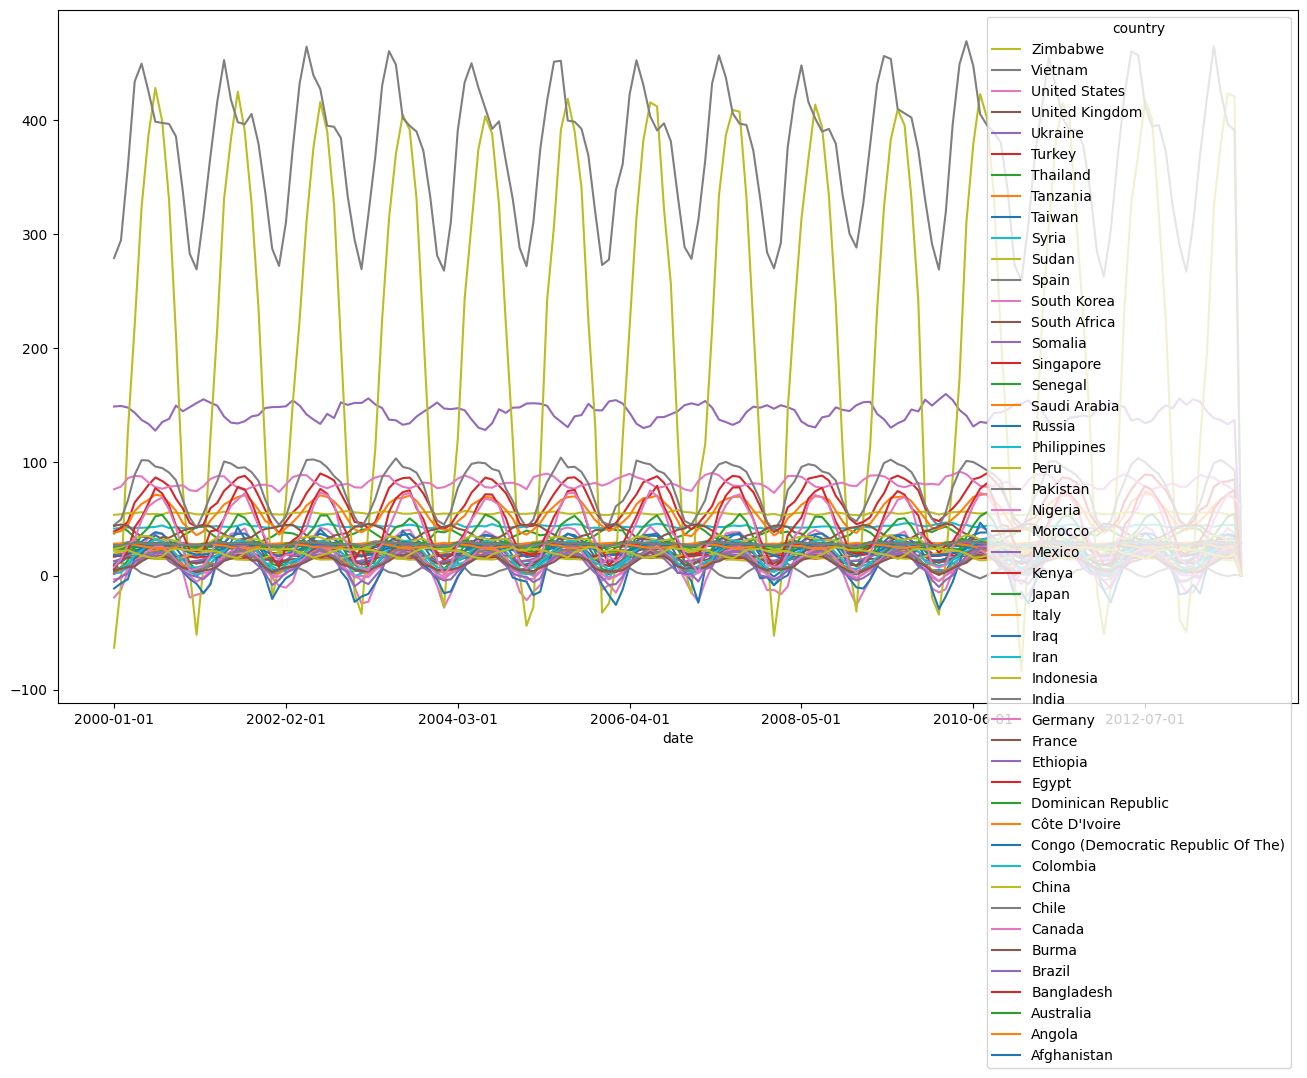

In [41]:
import matplotlib.pyplot as plt

new_dataset = pd.read_csv('temperatures.csv')

new_dataset1 = new_dataset.pivot_table(values='avg_temp_c', index=['date'], columns=['country'],fill_value=0, aggfunc=[ np.median,np.sum]).copy()
new_dataset1['sum'].plot(kind='line', legend='reverse', figsize=(16,9), )



In [42]:
help(pd.DataFrame.plot)

Help on class PlotAccessor in module pandas.plotting._core:

class PlotAccessor(pandas.core.base.PandasObject)
 |  PlotAccessor(data: 'Series | DataFrame') -> 'None'
 |  
 |  Make plots of Series or DataFrame.
 |  
 |  Uses the backend specified by the
 |  option ``plotting.backend``. By default, matplotlib is used.
 |  
 |  Parameters
 |  ----------
 |  data : Series or DataFrame
 |      The object for which the method is called.
 |  x : label or position, default None
 |      Only used if data is a DataFrame.
 |  y : label, position or list of label, positions, default None
 |      Allows plotting of one column versus another. Only used if data is a
 |      DataFrame.
 |  kind : str
 |      The kind of plot to produce:
 |  
 |      - 'line' : line plot (default)
 |      - 'bar' : vertical bar plot
 |      - 'barh' : horizontal bar plot
 |      - 'hist' : histogram
 |      - 'box' : boxplot
 |      - 'kde' : Kernel Density Estimation plot
 |      - 'density' : same as 'kde'
 |      - 

In [43]:
new_dataset = pd.read_csv('temperatures.csv')
new_dataset = new_dataset.set_index(keys=['country']).sort_index()
new_dataset.loc[["Côte D'Ivoire","Colombia"]]

,Unnamed: 0,date,city,avg_temp_c
country,,,,
Côte D'Ivoire,0,2000-01-01,Abidjan,27.293
Côte D'Ivoire,106,2008-11-01,Abidjan,27.302
Côte D'Ivoire,107,2008-12-01,Abidjan,27.472
Côte D'Ivoire,108,2009-01-01,Abidjan,26.912
Côte D'Ivoire,109,2009-02-01,Abidjan,28.224
...,...,...,...,...
Colombia,2693,2004-06-01,Cali,22.760
Colombia,2694,2004-07-01,Cali,22.500
Colombia,2695,2004-08-01,Cali,23.387


In [44]:
new_dataset

,Unnamed: 0,date,city,avg_temp_c
country,,,,
Afghanistan,7383,2010-04-01,Kabul,17.285
Afghanistan,7367,2008-12-01,Kabul,5.292
Afghanistan,7368,2009-01-01,Kabul,3.669
Afghanistan,7369,2009-02-01,Kabul,5.412
Afghanistan,7370,2009-03-01,Kabul,10.331
...,...,...,...,...
Zimbabwe,5501,2004-09-01,Harare,20.854
Zimbabwe,5502,2004-10-01,Harare,22.516
Zimbabwe,5503,2004-11-01,Harare,24.877


In [45]:
new_dataset = pd.read_csv('temperatures.csv')
new_dataset = new_dataset.set_index(keys=['country', 'city'])
new_dataset.loc[[("Côte D'Ivoire", 'Abidjan'),("Ethiopia", "Addis Abeba")]]

Unnamed: 0        date  avg_temp_c
country       city                                           
Côte D'Ivoire Abidjan               0  2000-01-01      27.293
              Abidjan               1  2000-02-01      27.685
              Abidjan               2  2000-03-01      29.061
              Abidjan               3  2000-04-01      28.162
              Abidjan               4  2000-05-01      27.547
...                               ...         ...         ...
Ethiopia      Addis Abeba         325  2013-05-01      19.774
              Addis Abeba         326  2013-06-01      18.736
              Addis Abeba         327  2013-07-01      18.148
              Addis Abeba         328  2013-08-01      19.005
              Addis Abeba         329  2013-09-01         NaN

[330 rows x 3 columns]

In [46]:
new_dataset.sort_index(level=['country',  'city'], ascending=[False, True])

Unnamed: 0        date  avg_temp_c
country     city                                      
Zimbabwe    Harare        5445  2000-01-01      22.119
            Harare        5446  2000-02-01      21.569
            Harare        5447  2000-03-01      22.370
            Harare        5448  2000-04-01      19.999
            Harare        5449  2000-05-01      17.703
...                        ...         ...         ...
Afghanistan Kabul         7420  2013-05-01      21.245
            Kabul         7421  2013-06-01      25.859
            Kabul         7422  2013-07-01      26.805
            Kabul         7423  2013-08-01      24.974
            Kabul         7424  2013-09-01         NaN

[16500 rows x 3 columns]

In [47]:
new_dataset.loc["Côte D'Ivoire":'India']

UnsortedIndexError: 'Key length (1) was greater than MultiIndex lexsort depth (0)'

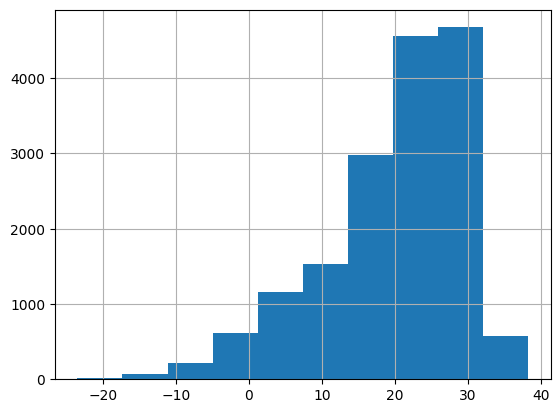

In [ ]:
new_dataset['avg_temp_c'].hist()
plt.show()

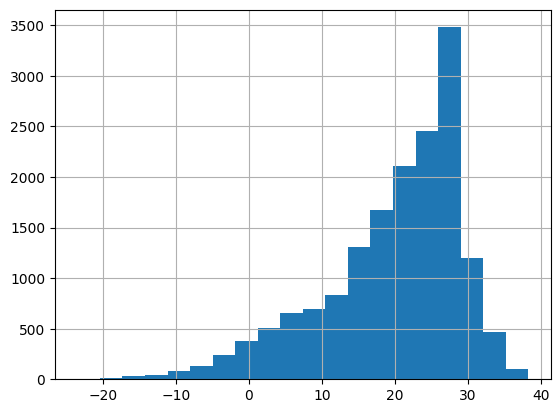

In [ ]:
new_dataset['avg_temp_c'].hist(bins=20)
plt.show()

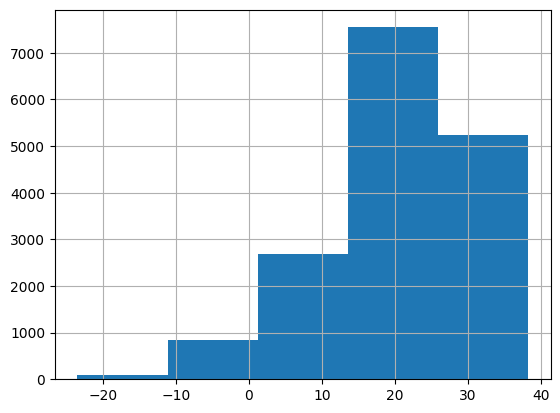

In [ ]:
new_dataset['avg_temp_c'].hist(bins=5)
plt.show()

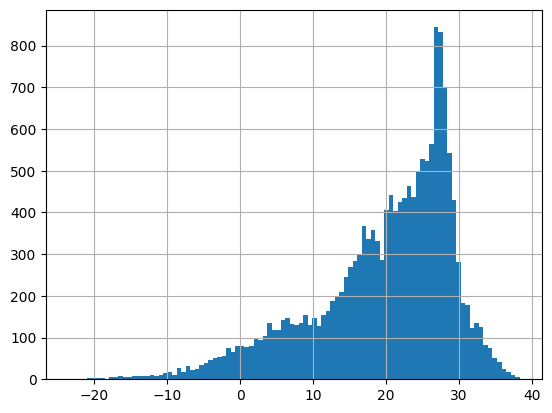

In [ ]:
new_dataset['avg_temp_c'].hist(bins=100)
plt.show()

In [48]:
new_dataset['avg_temp_c'].plot(kind='bar')
plt.show()

KeyboardInterrupt: 

In [ ]:
new_dataset['avg_temp_c'].plot(x='country', y='avg_temp_c', kind='line', rot=90, title='title of the graph')
plt.show()

KeyboardInterrupt: 